In [2]:
!mkdir -p /content/SDNET2018
!kaggle datasets download -d aniruddhsharma/structural-defects-network-concrete-crack-images \
    -p /content/SDNET2018

Dataset URL: https://www.kaggle.com/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images
License(s): other
100% 506M/506M [00:28<00:00, 18.5MB/s]



In [3]:
!ls -lh /content/SDNET2018

total 506M
-rw-r--r-- 1 root root 506M Jul 28  2020 structural-defects-network-concrete-crack-images.zip


In [4]:
import zipfile
import os
import glob

files = glob.glob("/content/SDNET2018/*.zip")

print(files)

['/content/SDNET2018/structural-defects-network-concrete-crack-images.zip']


In [5]:
zip_path = files[0]
extract_path = "/content/SDNET2018/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [6]:
for root, dirs, files in os.walk("/content/SDNET2018/data"):
    print(root, "->", len(files), "files")

/content/SDNET2018/data -> 0 files
/content/SDNET2018/data/Pavements -> 0 files
/content/SDNET2018/data/Pavements/Cracked -> 2608 files
/content/SDNET2018/data/Pavements/Non-cracked -> 21726 files
/content/SDNET2018/data/Walls -> 0 files
/content/SDNET2018/data/Walls/Cracked -> 3851 files
/content/SDNET2018/data/Walls/Non-cracked -> 14287 files
/content/SDNET2018/data/Decks -> 0 files
/content/SDNET2018/data/Decks/Cracked -> 2025 files
/content/SDNET2018/data/Decks/Non-cracked -> 11595 files


In [7]:
import os

base_path = "/content/SDNET2018/data"

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level < 3:
        for file in files[:5]:
            print(f"{indent}    {file}")

data/
    Pavements/
        Cracked/
            100-74.jpg
            085-96.jpg
            044-79.jpg
            071-50.jpg
            061-107.jpg
        Non-cracked/
            063-201.jpg
            069-31.jpg
            062-10.jpg
            061-71.jpg
            006-128.jpg
    Walls/
        Cracked/
            7124-60.jpg
            7073-24.jpg
            7092-135.jpg
            7093-9.jpg
            7140-47_2.jpg
        Non-cracked/
            7103-36.jpg
            7103-21.jpg
            7137-166.jpg
            7106-24.jpg
            7133-138.jpg
    Decks/
        Cracked/
            7029-139.jpg
            7002-85.jpg
            7026-241.jpg
            7026-74.jpg
            7003-195.jpg
        Non-cracked/
            7001-141.jpg
            7005-22.jpg
            7053-65.jpg
            7030-245.jpg
            7054-24.jpg


In [8]:
import glob
import os

image_extensions = ["*.jpg", "*.JPG", "*.jpeg", "*.JPEG", "*.png", "*.PNG"]

image_paths = []

for ext in image_extensions:
    image_paths.extend(
        glob.glob(f"{base_path}/**/{ext}", recursive=True)
    )

print("Total images:", len(image_paths))

print("\nFirst 20 images:")
for path in image_paths[:20]:
    print(path)

Total images: 56092

First 20 images:
/content/SDNET2018/data/Pavements/Cracked/100-74.jpg
/content/SDNET2018/data/Pavements/Cracked/085-96.jpg
/content/SDNET2018/data/Pavements/Cracked/044-79.jpg
/content/SDNET2018/data/Pavements/Cracked/071-50.jpg
/content/SDNET2018/data/Pavements/Cracked/061-107.jpg
/content/SDNET2018/data/Pavements/Cracked/019-138.jpg
/content/SDNET2018/data/Pavements/Cracked/089-61.jpg
/content/SDNET2018/data/Pavements/Cracked/029-119.jpg
/content/SDNET2018/data/Pavements/Cracked/028-157.jpg
/content/SDNET2018/data/Pavements/Cracked/010-114.jpg
/content/SDNET2018/data/Pavements/Cracked/071-8.jpg
/content/SDNET2018/data/Pavements/Cracked/047-87.jpg
/content/SDNET2018/data/Pavements/Cracked/057-130.jpg
/content/SDNET2018/data/Pavements/Cracked/099-99.jpg
/content/SDNET2018/data/Pavements/Cracked/092-102.jpg
/content/SDNET2018/data/Pavements/Cracked/018-102.jpg
/content/SDNET2018/data/Pavements/Cracked/088-43.jpg
/content/SDNET2018/data/Pavements/Cracked/019-140.jpg


In [9]:
from pathlib import Path

folders = set()

for path in image_paths:
    folders.add(Path(path).parent.name)

print("Image-containing folders:")
for folder in sorted(folders):
    print(folder)

Image-containing folders:
Cracked
Non-cracked


In [10]:
import pandas as pd
from pathlib import Path

data = []

for path in image_paths:
    parent = Path(path).parent.name.lower()

    data.append({
        "image_path": path,
        "folder": parent
    })

df = pd.DataFrame(data)

print(df.head())
print("\nTotal:", len(df))
print("\nFolder distribution:")
print(df["folder"].value_counts())

                                          image_path   folder
0  /content/SDNET2018/data/Pavements/Cracked/100-...  cracked
1  /content/SDNET2018/data/Pavements/Cracked/085-...  cracked
2  /content/SDNET2018/data/Pavements/Cracked/044-...  cracked
3  /content/SDNET2018/data/Pavements/Cracked/071-...  cracked
4  /content/SDNET2018/data/Pavements/Cracked/061-...  cracked

Total: 56092

Folder distribution:
folder
non-cracked    47608
cracked         8484
Name: count, dtype: int64


In [11]:
df["label"] = df["folder"].apply(
    lambda x: 1 if "crack" in x and "non" not in x else 0
)

In [12]:
print(df["label"].value_counts())

label
0    47608
1     8484
Name: count, dtype: int64


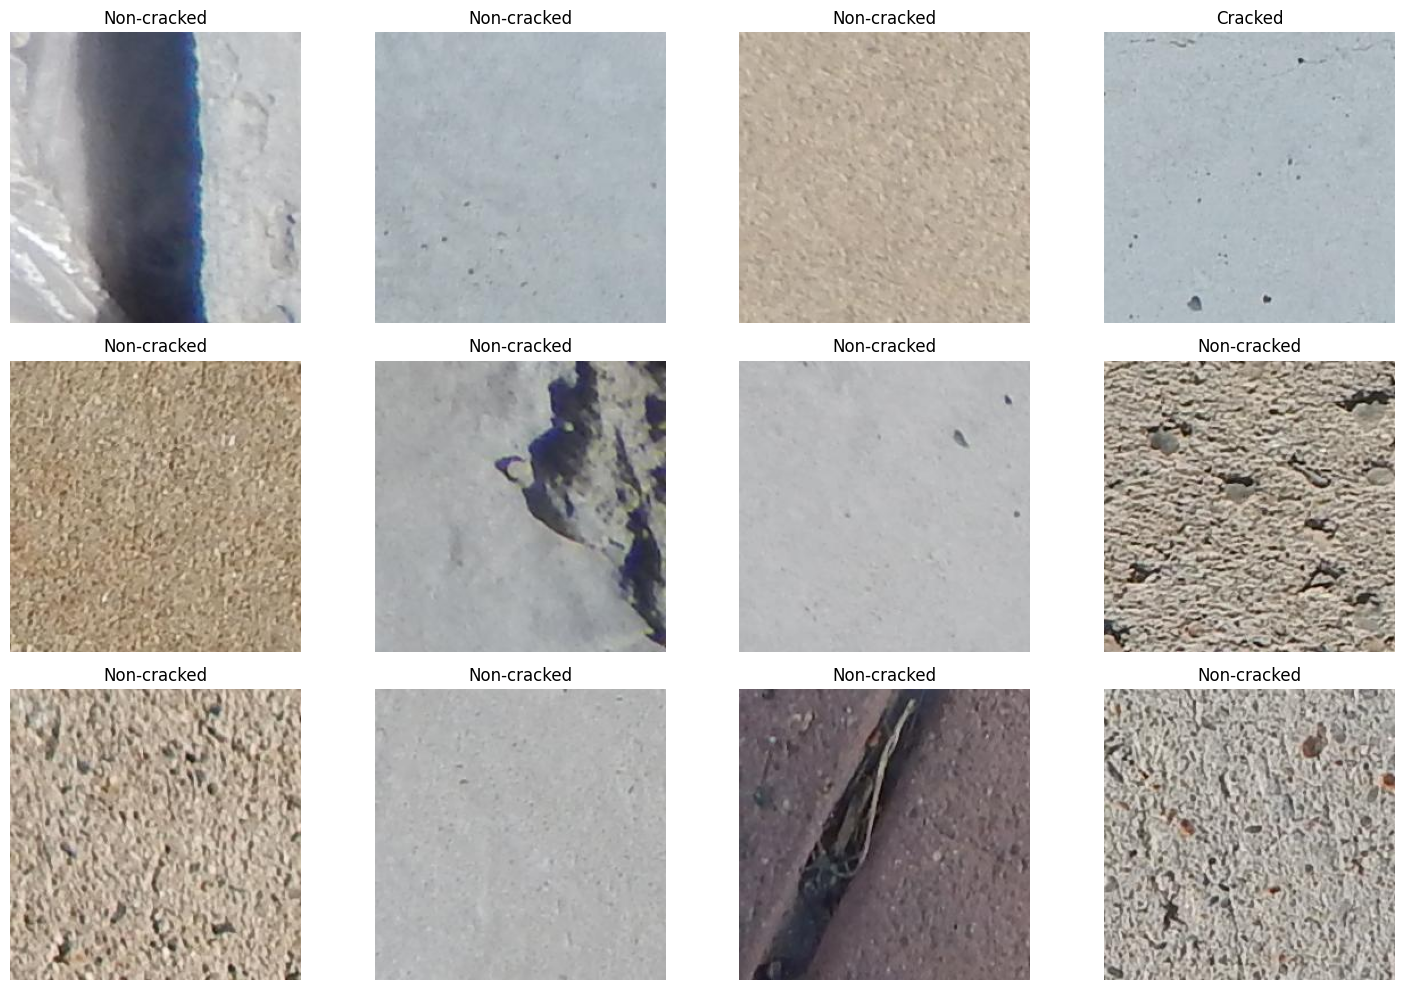

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_paths = random.sample(image_paths, min(12, len(image_paths)))

plt.figure(figsize=(15, 10))

for i, path in enumerate(sample_paths):
    img = Image.open(path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(Path(path).parent.name)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 39264
Validation: 8414
Testing: 8414


In [15]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
Device: cuda


In [16]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class CrackDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [17]:
#Image preprocessing + augmentation
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [18]:
train_dataset = CrackDataset(
    train_df,
    transform=train_transform
)

val_dataset = CrackDataset(
    val_df,
    transform=test_transform
)

test_dataset = CrackDataset(
    test_df,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created!")

DataLoaders created!


In [19]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

# Replace final layer
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


Linear(in_features=512, out_features=2, bias=True)


In [20]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [21]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Accuracy: {train_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.2508 Accuracy: 91.15%
Epoch [2/5] Loss: 0.2045 Accuracy: 92.87%
Epoch [3/5] Loss: 0.1890 Accuracy: 93.47%
Epoch [4/5] Loss: 0.1774 Accuracy: 93.93%
Epoch [5/5] Loss: 0.1712 Accuracy: 94.12%


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

print(classification_report(
    all_labels,
    all_predictions,
    target_names=["No Crack", "Crack"]
))

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)
#     PNC PC
# ANC TN  FP
# AC  FN  TP

              precision    recall  f1-score   support

    No Crack       0.95      0.98      0.97      7142
       Crack       0.89      0.71      0.79      1272

    accuracy                           0.94      8414
   macro avg       0.92      0.84      0.88      8414
weighted avg       0.94      0.94      0.94      8414

Confusion Matrix:
[[7030  112]
 [ 375  897]]
